In [13]:
import os
import sys
import random
import numpy as np
import torch
import subprocess
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import json
from glob import glob
import gzip
from PIL import Image
from torchvision import transforms as transforms
from typing import List, Optional
from torch.utils.data import Dataset, DataLoader
import warnings
import co3d
from co3d.dataset.data_types import (
    load_dataclass_jgzip,
    FrameAnnotation,
    SequenceAnnotation,
)
from pathlib import Path

In [14]:
CATEGORIES = [
    "apple",
    "backpack",
    "ball",
    "banana",
    "baseballbat",
    "baseballglove",
    "bench",
    "bicycle",
    "book",
    "bottle",
    "bowl",
    "broccoli",
    "cake",
    "car",
    "carrot",
    "cellphone",
    "chair",
    "couch",
    "cup",
    "donut",
    "frisbee",
    "hairdryer",
    "handbag",
    "hotdog",
    "hydrant",
    "keyboard",
    "kite",
    "laptop",
    "microwave",
    "motorcycle",
    "mouse",
    "orange",
    "parkingmeter",
    "pizza",
    "plant",
    "remote",
    "sandwich",
    "skateboard",
    "stopsign",
    "suitcase",
    "teddybear",
    "toaster",
    "toilet",
    "toybus",
    "toyplane",
    "toytrain",
    "toytruck",
    "tv",
    "umbrella",
    "vase",
    "wineglass",
]

In [15]:
CATEGORY = "book"
ROOT_DIR = "/data/lab_moezkan/co3d_full"
BBOX_FILE = os.path.join(ROOT_DIR, "book_bbox.jgz")

if os.path.exists(BBOX_FILE):
    print(f"SUCCESS: BBox file exists under: {BBOX_FILE}")
else:
    print("BBox file not found.")

BBox file not found.


In [16]:
BBOX_OUT_DIR = "/data/lab_moezkan/co3d_bboxes"

In [17]:
import sys

sys.path.append("..")

In [18]:
from preprocess_co3d import process_poses

In [19]:
# bbox_file_path = precompute_bbox(
#     co3d_dir=ROOT_DIR,
#     category="book",
#     output_dir=BBOX_OUT_DIR
# )

In [8]:
%run "../preprocess_co3d.py" --precompute_bbox --category "toybus" --output_dir "/data/lab_moezkan/co3d_bboxes" --co3d_v2_dir "/data/lab_moezkan/co3d_full"


Precomputing bbox for: toybus


  0%|          | 0/46859 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [44]:
%run "../preprocess_co3d.py" --category "toybus" --output_dir "/data/lab_moezkan/co3d_bboxes" --co3d_v2_dir "/data/lab_moezkan/co3d_full"

Processing category: toybus
Loading precomputed bbox from: /data/lab_moezkan/co3d_bboxes/toybus_bbox.jgz


In [9]:
import gzip
import json
from typing import cast, IO
# toybus_test.jgz


file = "/data/lab_moezkan/co3d_bboxes/toybus_test.jgz"
with gzip.GzipFile(file, "rb") as f:
    asdict = json.loads(cast(IO, f).read().decode("utf8"))

In [11]:
samples = []
for subdir in asdict.keys():
    for sample in asdict[subdir]:
        samples.append(sample)

len(samples)

4798

{'filepath': 'toybus/121_14153_28986/images/frame000009.jpg',
 'R': [[-0.6064592599868774, 0.6477743983268738, 0.46108072996139526],
  [-0.670051097869873, -0.7285599112510681, 0.14223921298980713],
  [0.42806386947631836, -0.22268536686897278, 0.8758838772773743]],
 'T': [1.1168477535247803, 4.90004825592041, 14.350221633911133],
 'focal_length': [3.566190242767334, 3.566190242767334],
 'principal_point': [-0.0, -0.000985221704468131],
 'bbox': [217, 77, 536, 765]}

In [26]:
from typing import Optional
from data_process.co3d_dataset import jitter_bbox, square_bbox
from dataclasses import dataclass
from pathlib import Path
from torchvision import transforms

from data_process.plucker import plucker_encodeing
from typing import cast, IO



@dataclass
class Co3DSample:
    """Dataclass representing a single CO3D sample."""

    filepath: str
    R: List[List[float]]
    T: List[float]
    focal_length: List[float]
    principal_point: List[float]
    bbox: List[int]


class ProcessedCo3D(Dataset):
    def __init__(
        self,
        co3d_dir: str,
        bb_file: str,
        apply_augmentation: bool = False,
        transform: Optional[transforms.Compose] = None,
        patch_num: Optional[int] = None,
        crop_images: bool = False,
        device: Optional[str] = None,
    ):
        """Dataset for the preprocessed CO3D data.

        Args:
            co3d_dir (str): Path to the image directory.
            bb_fiel (str): Path to the single object bbox file.
            apply_augmentation (bool, optional): Determines if jitter augs should be applied to bboxes. Defaults to False.
            transform (Optional[transforms.Compose], optional): Transform obj containing image trans. Defaults to Norm+See Code.
            patch_num (Optional[int], optional): Number of patches for one dim. Final plücker dim will be (n_patches, n_patches). Defaults to None (use only one).
        """
        super().__init__()
        self.co3d_dir = Path(co3d_dir)
        self.bbox_file = bb_file
        self.crop_images = crop_images
        self.device = device
        self.patch_num = patch_num
        
        self.samples = []
        with gzip.GzipFile(self.bbox_file, "rb") as f:
            obj_dict = json.loads(cast(IO, f).read().decode("utf8"))

        for subdir in obj_dict.keys():
            for sample in obj_dict[subdir]:
                self.samples.append(sample)

        self.transform = transform
        if self.transform is None:
            self.transform = transforms.Compose(
                [
                    transforms.Resize((512, 512), antialias=True),
                    transforms.ToTensor(),
                    transforms.Normalize([0.5], [0.5]),
                ]
            )

        self.apply_augmentation = apply_augmentation
        if self.apply_augmentation:
            self.jitter_scale = (1.1, 1.2)
            self.jitter_trans = (-0.07, 0.07)
        else:
            # Note if trained with apply_augmentation, we should still use
            # apply_augmentation at test time.
            self.jitter_scale = (1, 1)
            self.jitter_trans = (0.0, 0.0)

    def _crop_image(self, image, bbox):
        image_crop = transforms.functional.crop(
            image,
            top=bbox[1],
            left=bbox[0],
            height=bbox[3] - bbox[1],
            width=bbox[2] - bbox[0],
        )
        return image_crop

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample: Co3DSample = self.samples[idx]

        # convert to torch tensor
        source_image = Image.open(self.co3d_dir / sample["filepath"])
        image = transforms.ToTensor()(source_image)  # c w h
        orig_h, orig_w = image.size()[1:]

        bbox = sample["bbox"]
        bbox_init = bbox if self.crop_images else [0, 0, orig_h, orig_w]
        bbox = square_bbox(np.array(bbox_init))

        if self.apply_augmentation:
            bbox = jitter_bbox(
                bbox,
                jitter_scale=self.jitter_scale,
                jitter_trans=self.jitter_trans,
            )

        rounded_bb = np.around(bbox).astype(int)

        # crop handling
        crop_center = (bbox[:2] + bbox[2:]) / 2
        # convert crop center to correspond to a "square" image
        max_dimension = max(orig_w, orig_h)
        crop_center_adjusted = (
            crop_center + (max_dimension - np.array([orig_w, orig_h])) / 2
        )

        # convert to NDC
        scale_fact = max_dimension / min(orig_w, orig_h)
        ndc_center = scale_fact - 2 * scale_fact * crop_center_adjusted / max_dimension
        crop_width_ndc = (
            2 * scale_fact * (rounded_bb[2] - rounded_bb[0]) / max_dimension
        )
        crop_params = torch.tensor(
            [-ndc_center[0], -ndc_center[1], crop_width_ndc, scale_fact],
            dtype=torch.float32,
        )

        # crop and normalize the image
        image_cropped = self._crop_image(image=source_image, bbox=rounded_bb)
        image_cropped = self.transform(image_cropped)
        cropped_size = (image_cropped.shape[1], image_cropped.shape[2])

        rot = torch.tensor(sample["R"], dtype=torch.float32)
        trans = torch.tensor(sample["T"], dtype=torch.float32)
        focal_length = torch.tensor(sample["focal_length"], dtype=torch.float32)
        principle_point = torch.tensor(sample["principal_point"], dtype=torch.float32)

        plucker = plucker_encodeing(
            R=rot,
            T=trans,
            fl=focal_length,
            pp=principle_point,
            crop_params=crop_params,
            original_size=(orig_h, orig_w),
            cropped_size=cropped_size,
            device=self.device,
            patch_num=self.patch_num,
        )

        return {"source": source_image, "image": image_cropped, "pluck": plucker}


In [27]:
test_data = ProcessedCo3D(
    co3d_dir=ROOT_DIR,
    bb_file="/data/lab_moezkan/co3d_bboxes/toybus_test.jgz",
    apply_augmentation=True,
    crop_images=True,
    patch_num=16
)

In [28]:
s_im, im, pluck = test_data[0]

In [35]:
pluck[:, 3:][:10]

tensor([[-2608.7976, -1240.5131,  2230.6843],
        [-2230.9929,  -733.0432,  1950.1823],
        [-1853.1881,  -225.5732,  1669.6803],
        [-1475.3835,   281.8967,  1389.1783],
        [-1097.5789,   789.3666,  1108.6764],
        [ -719.7743,  1296.8365,   828.1745],
        [ -341.9696,  1804.3064,   547.6725],
        [   35.8350,  2311.7764,   267.1706],
        [  413.6396,  2819.2461,   -13.3312],
        [  791.4443,  3326.7158,  -293.8333]])

In [34]:
pluck[:, :3][:10]

tensor([[  39.3548, -239.4290,  -87.1240],
        [  11.8324, -206.1260,  -63.9434],
        [ -15.6900, -172.8229,  -40.7628],
        [ -43.2124, -139.5198,  -17.5822],
        [ -70.7349, -106.2168,    5.5985],
        [ -98.2573,  -72.9137,   28.7791],
        [-125.7797,  -39.6106,   51.9597],
        [-153.3021,   -6.3076,   75.1403],
        [-180.8245,   26.9955,   98.3209],
        [-208.3469,   60.2986,  121.5015]])

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

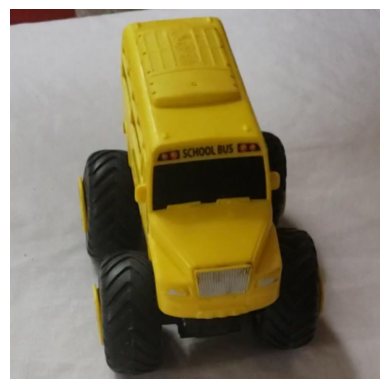

In [104]:
plt.imshow((im.permute(1, 2, 0).numpy() * 0.5 + 0.5))
plt.axis("off")

In [1]:
import sys
sys.path.append("..")

In [7]:
from omegaconf import OmegaConf
from ldm.models.autoencoder import AutoencoderKL
import torch 
config = OmegaConf.load("../vae_config.yaml")

config

{'model': {'target': 'ldm.models.autoencoder.AutoencoderKL', 'params': {'embed_dim': 4, 'monitor': 'val/rec_loss', 'ddconfig': {'double_z': True, 'z_channels': 4, 'resolution': 256, 'in_channels': 3, 'out_ch': 3, 'ch': 128, 'ch_mult': [1, 2, 4, 4], 'num_res_blocks': 2, 'attn_resolutions': [], 'dropout': 0.0}, 'lossconfig': {'target': 'torch.nn.Identity'}}}}

In [10]:

vae = AutoencoderKL(
    ddconfig=config.model.params.ddconfig,
    lossconfig=config.model.params.lossconfig,
    embed_dim=config.model.params.embed_dim,
)
vae = vae.to("cuda")

making attention of type 'vanilla-xformers' with 512 in_channels
building MemoryEfficientAttnBlock with 512 in_channels...
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla-xformers' with 512 in_channels
building MemoryEfficientAttnBlock with 512 in_channels...


In [8]:
sample_im = torch.randn(1, 3, 512, 512)
sample_im.shape

torch.Size([1, 3, 512, 512])

In [11]:
h = vae.encoder(sample_im.to("cuda"))
h

tensor([[[[ 1.2160e-01,  2.1408e-01, -1.0453e-01,  ..., -2.5705e-01,
            1.5201e-01, -1.6565e-01],
          [ 1.6526e-01,  1.6222e-02,  1.9658e-01,  ..., -7.1124e-02,
           -9.2949e-02, -3.4222e-01],
          [ 1.9651e-01,  1.9244e-01, -1.2489e-01,  ..., -1.9968e-02,
           -7.3345e-03, -1.7023e-01],
          ...,
          [ 1.2900e-01,  1.4050e-01, -8.4471e-02,  ..., -1.9981e-01,
           -4.8795e-01, -1.5392e-01],
          [ 7.8533e-02,  4.5523e-02, -1.0995e-01,  ..., -3.2761e-01,
            9.4032e-02, -2.4744e-01],
          [ 1.2565e-01,  5.6262e-02,  2.8108e-01,  ...,  7.5687e-02,
            1.7096e-01, -6.6185e-02]],

         [[-8.2720e-02, -2.1105e-01, -2.2462e-01,  ..., -1.1750e-01,
           -2.1554e-02,  3.4985e-02],
          [-2.3506e-01, -3.2379e-01, -5.0404e-01,  ..., -1.6476e-01,
           -1.3631e-01,  1.3045e-01],
          [-3.0951e-01, -2.7038e-01, -6.1974e-01,  ..., -1.8927e-01,
           -2.1714e-01, -7.0785e-02],
          ...,
     

In [12]:
h.shape

torch.Size([1, 8, 64, 64])